# Simplified Diffusion Model (DDPM)

Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


Dataset
Generate 800 simple 8×8 binary patterns with a tiny bit of random noise added.

Dataset shape: (800, 64)


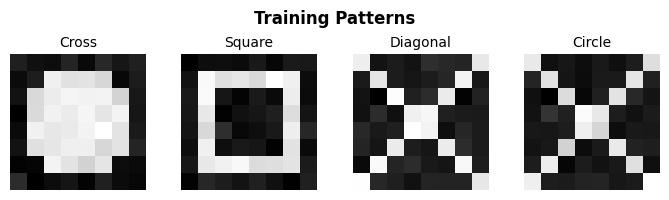

In [3]:
def make_dataset(n = 800):
    data = []
    for _ in range(n):
        img = np.zeros((8 , 8))
        kind = np.random.randint(4)
        if kind == 0:          # cross
            img[3, :] = 1; img[:, 3] = 1
        elif kind == 1:        # hollow square
            img[1:7, 1] = 1; img[1:7, 6] = 1
            img[1, 1:7] = 1; img[6, 1:7] = 1
        elif kind == 2:        # diagonal X
            for i in range(8): img[i, i] = 1
            for i in range(8): img[i, 7-i] = 1
        else:                  # filled circle
            cx, cy = 3.5, 3.5
            for r in range(8):
                for c in range(8):
                    if (r-cx)**2 + (c-cy)**2 < 9:
                        img[r, c] = 1
        img += np.random.randn(8, 8) * 0.05   # slight noise
        data.append(img.flatten())
    return np.array(data, dtype=np.float32)    # shape: (N, 64)

data = make_dataset(800)
print(f'Dataset shape: {data.shape}')

# Preview the 4 pattern types
fig, axes = plt.subplots(1, 4, figsize=(7, 2))
labels = ['Cross', 'Square', 'Diagonal', 'Circle']
for i, ax in enumerate(axes):
    ax.imshow(data[i*200].reshape(8,8), cmap='gray', interpolation='nearest')
    ax.set_title(labels[i], fontsize=10)
    ax.axis('off')
plt.suptitle('Training Patterns', fontweight='bold')
plt.tight_layout()
plt.show()

Noise Schedule
The **cosine schedule** controls how much noise is added at each timestep.
At t=0 the image is clean; at t=99 it is pure Gaussian noise.

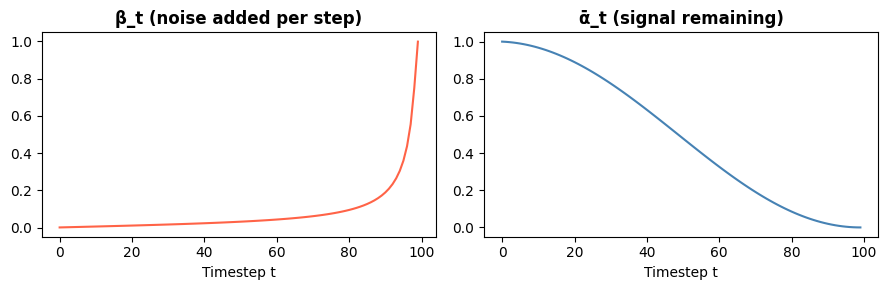

In [4]:
T = 100   # total diffusion timesteps

def cosine_beta_schedule(T):
    """Smooth cosine schedule — avoids destroying signal too fast."""
    steps = np.arange(T + 1)
    alpha_bar = np.cos(((steps / T) + 0.008) / 1.008 * np.pi / 2) ** 2
    alpha_bar = alpha_bar / alpha_bar[0]
    betas = np.clip(1 - alpha_bar[1:] / alpha_bar[:-1], 0, 0.999)
    return betas.astype(np.float32)

betas      = cosine_beta_schedule(T)
alphas     = 1.0 - betas
alpha_bars = np.cumprod(alphas)   # cumulative product: how much signal remains at step t

# Plot schedule
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(betas, color='tomato')
axes[0].set_title('β_t (noise added per step)', fontweight='bold')
axes[0].set_xlabel('Timestep t')
axes[1].plot(alpha_bars, color='steelblue')
axes[1].set_title('ᾱ_t (signal remaining)', fontweight='bold')
axes[1].set_xlabel('Timestep t')
plt.tight_layout()
plt.show()

Forward Process
Given a clean image x₀ and timestep t, we can jump directly to the noisy version using:

$$x_t = \sqrt{\bar{\alpha}_t} \cdot x_0 + \sqrt{1 - \bar{\alpha}_t} \cdot \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, I)$$

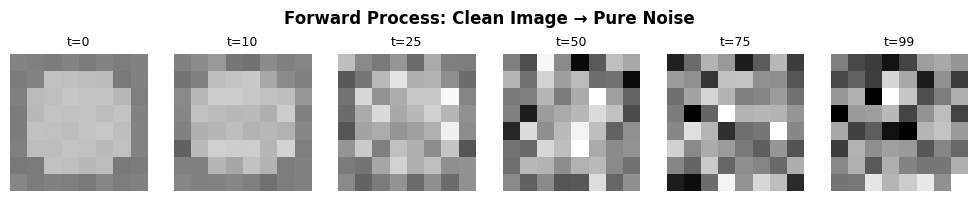

In [5]:
def q_sample(x0, t, noise=None):
    """Add noise to a batch of images at given timesteps."""
    if noise is None:
        noise = np.random.randn(*x0.shape).astype(np.float32)
    ab = alpha_bars[t][:, None]   # (B, 1)
    return np.sqrt(ab) * x0 + np.sqrt(1 - ab) * noise, noise

# Visualise forward process on one image
sample = data[0:1]   # shape (1, 64)
ts_show = [0, 10, 25, 50, 75, 99]

fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for ax, t_val in zip(axes, ts_show):
    noisy, _ = q_sample(sample, np.array([t_val]))
    ax.imshow(noisy.reshape(8, 8), cmap='gray', vmin=-2, vmax=2, interpolation='nearest')
    ax.set_title(f't={t_val}', fontsize=9)
    ax.axis('off')
plt.suptitle('Forward Process: Clean Image → Pure Noise', fontweight='bold')
plt.tight_layout()
plt.show()

Model: MLP Noise Predictor
The neural network takes a noisy image **x_t** and a **time embedding e(t)** and predicts the noise **ε** that was added.

```
Input:  [x_t (64) | e(t) (32)]  →  96 dims
         ↓
    Linear(96 → 128) + ReLU
         ↓
    Linear(128 → 128) + ReLU
         ↓
    Linear(128 → 64)    ← predicted noise ε̂
```
Total trainable parameters: **37,120**

In [6]:
D   = 64    # image size (8×8 flattened)
EMB = 32    # time embedding size
H   = 128   # hidden layer size

def sinusoidal_embedding(t, dim=EMB):
    half = dim // 2
    freqs = np.exp(-np.log(10000) * np.arange(half) / half).astype(np.float32)
    args  = t[:, None] * freqs[None, :]                          # (B, half)
    return np.concatenate([np.sin(args), np.cos(args)], axis=-1) # (B, dim)

class DiffusionMLP:

    def __init__(self):
        scale = 0.1
        self.W1 = np.random.randn(D + EMB, H).astype(np.float32) * scale
        self.b1 = np.zeros(H, dtype=np.float32)
        self.W2 = np.random.randn(H, H).astype(np.float32) * scale
        self.b2 = np.zeros(H, dtype=np.float32)
        self.W3 = np.random.randn(H, D).astype(np.float32) * scale
        self.b3 = np.zeros(D, dtype=np.float32)

    def params(self):
        return [self.W1, self.b1, self.W2, self.b2, self.W3, self.b3]

    def forward(self, x, t_emb):
        """x: (B, 64), t_emb: (B, 32) → predicted noise (B, 64)"""
        h = np.concatenate([x, t_emb], axis=-1)  # (B, 96)
        h = np.maximum(h @ self.W1 + self.b1, 0) # Linear + ReLU
        h = np.maximum(h @ self.W2 + self.b2, 0) # Linear + ReLU
        return h @ self.W3 + self.b3              # Linear (no activation)

    def backward(self, x, t_emb, target_noise, lr=3e-3):
        """One step of manual backpropagation. Returns MSE loss."""
        B   = x.shape[0]
        inp = np.concatenate([x, t_emb], axis=-1)

        # Forward (save activations for backprop)
        z1   = inp @ self.W1 + self.b1
        a1   = np.maximum(z1, 0)
        z2   = a1  @ self.W2 + self.b2
        a2   = np.maximum(z2, 0)
        pred = a2  @ self.W3 + self.b3

        # Loss: MSE between predicted and actual noise
        diff = pred - target_noise
        loss = np.mean(diff ** 2)

        # Backward
        d = 2 * diff / B
        dW3 = a2.T @ d;            db3 = d.sum(0);       d = d @ self.W3.T
        d  *= (z2 > 0)             # ReLU gradient
        dW2 = a1.T @ d;            db2 = d.sum(0);       d = d @ self.W2.T
        d  *= (z1 > 0)             # ReLU gradient
        dW1 = inp.T @ d;           db1 = d.sum(0)

        # Gradient clipping + SGD update
        for param, grad in zip(self.params(), [dW1, db1, dW2, db2, dW3, db3]):
            param -= lr * np.clip(grad, -1, 1)

        return loss

model = DiffusionMLP()
total_params = sum(p.size for p in model.params())
print(f'Model created. Total parameters: {total_params:,}')

Model created. Total parameters: 37,184


Training
At each step we:
1. Pick random images and random timesteps
2. Add noise to create **x_t**
3. Ask the model to predict the noise
4. Minimise **MSE(predicted_noise, actual_noise)**

In [7]:
def train(model, data, epochs = 400, batch_size = 64, lr = 3e-3):
    N = len(data)
    losses = []
    for epoch in range(epochs):
        idx = np.random.permutation(N)
        epoch_loss, steps = 0.0, 0
        for i in range(0, N, batch_size):
            batch = data[idx[i:i+batch_size]]
            t     = np.random.randint(0, T, size=len(batch))
            x_t, noise = q_sample(batch, t)
            t_emb = sinusoidal_embedding(t)
            epoch_loss += model.backward(x_t, t_emb, noise, lr=lr)
            steps += 1
        losses.append(epoch_loss / steps)
        if (epoch + 1) % 50 == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs}  loss = {losses[-1]:.4f}')
    return losses

print('Training …')
losses = train(model, data, epochs = 400, lr = 3e-3)
print(f'Done! Final loss: {losses[-1]:.4f}')

Training …
  Epoch  50/400  loss = 0.3768
  Epoch 100/400  loss = 0.2367
  Epoch 150/400  loss = 0.2323
  Epoch 200/400  loss = 0.2350
  Epoch 250/400  loss = 0.2124
  Epoch 300/400  loss = 0.2042
  Epoch 350/400  loss = 0.2203
  Epoch 400/400  loss = 0.2032
Done! Final loss: 0.2032


Training Loss Curve

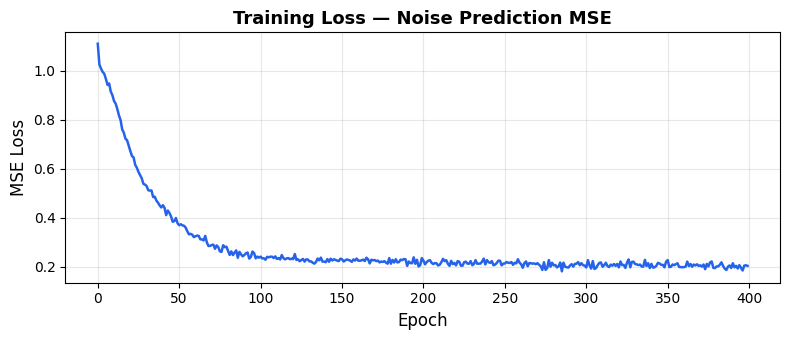

Loss went from 1.1100 → 0.2032


In [9]:
fig, ax = plt.subplots(figsize=(8 , 3.5))
ax.plot(losses, color = '#2563eb', lw = 1.8)
ax.set_xlabel('Epoch', fontsize = 12)
ax.set_ylabel('MSE Loss', fontsize = 12)
ax.set_title('Training Loss — Noise Prediction MSE', fontsize = 13, fontweight = 'bold')
ax.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()
print(f'Loss went from {losses[0]:.4f} → {losses[-1]:.4f}')

Sampling (Reverse Process)
To generate an image we start from pure Gaussian noise and iteratively denoise using:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}}\,\hat{\varepsilon}_\theta\right) + \sqrt{\beta_t}\,z, \quad z \sim \mathcal{N}(0,I)$$

In [10]:
def p_sample(model, x, t_scalar):
    t_arr = np.array([t_scalar], dtype=np.int32)
    t_emb = sinusoidal_embedding(t_arr)
    eps   = model.forward(x[None], t_emb)[0]  # predicted noise

    coef = (1 - alphas[t_scalar]) / np.sqrt(1 - alpha_bars[t_scalar])
    mean = (x - coef * eps) / np.sqrt(alphas[t_scalar])

    if t_scalar == 0:
        return mean
    return mean + np.sqrt(betas[t_scalar]) * np.random.randn(*x.shape).astype(np.float32)

def generate_samples(model, n = 16):
    samples = []
    for _ in range(n):
        x = np.random.randn(D).astype(np.float32)  # start from noise
        for t in reversed(range(T)):               # denoise step by step
            x = p_sample(model, x, t)
        samples.append(x.reshape(8, 8))
    return samples

print('Generating 16 samples …')
samples = generate_samples(model, n = 16)
print('Done!')

Generating 16 samples …
Done!


Visualise Generated Images

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for ax, img in zip(axes.flat, samples):
    ax.imshow(img, cmap='gray', vmin = -0.5, vmax = 1.5, interpolation = 'nearest')
    ax.axis('off')
plt.suptitle('Generated Samples (noise → image via 100 reverse steps)', fontweight = 'bold')
plt.tight_layout()
plt.show()

Reverse Process Visualisation
Watch a single image being gradually denoised from pure noise to a pattern.

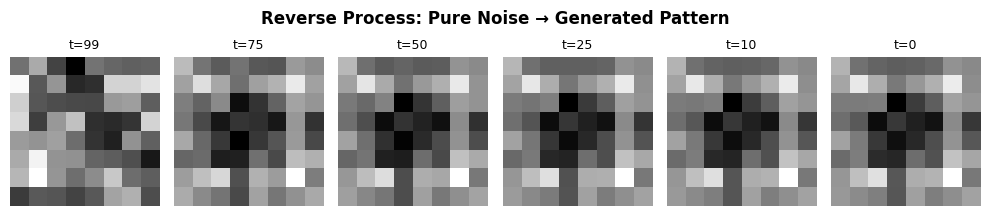

In [11]:
# Run one full reverse chain and save snapshots
x = np.random.randn(D).astype(np.float32)
snapshots = {99: x.reshape(8, 8).copy()}
for t in reversed(range(T)):
    x = p_sample(model, x, t)
    if t in [75, 50, 25, 10, 0]:
        snapshots[t] = x.reshape(8, 8).copy()

fig, axes = plt.subplots(1, 6, figsize = (10, 2.2))
for ax, t_val in zip(axes, [99, 75, 50, 25, 10, 0]):
    ax.imshow(snapshots[t_val], cmap='gray', interpolation='nearest')
    ax.set_title(f't={t_val}', fontsize=9)
    ax.axis('off')
plt.suptitle('Reverse Process: Pure Noise → Generated Pattern', fontweight='bold')
plt.tight_layout()
plt.show()